In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files

In [ ]:
uploaded = files.upload()

Saving voltage_stability_dataset.csv to voltage_stability_dataset.csv


In [ ]:
df = pd.read_csv('voltage_stability_dataset.csv')

In [ ]:
df.head()

,Bus ID,Voltage Magnitude,Voltage Angle,freq_hz,Load Factor,Line Outage,Stability Label
0,0,1.030957,40.330800,50.002858,0.6,0,STABLE
1,1,1.014978,58.253833,50.009634,0.6,0,STABLE
2,2,0.971241,52.192754,49.991081,0.6,0,STABLE
3,3,0.922611,40.375760,49.978707,0.6,0,STABLE
4,4,0.915772,32.559313,50.001585,0.6,0,STABLE


In [ ]:
df.describe()

,Bus ID,Voltage Magnitude,Voltage Angle,freq_hz,Load Factor,Line Outage
count,18213.000000,18149.000000,18149.000000,18213.000000,18213.000000,18213.000000
mean,19.000000,1.010827,5.837427,49.999801,0.899358,16.473233
std,11.254938,0.035353,31.442676,0.009971,0.186772,10.383563
min,0.000000,0.789483,-75.518485,49.960162,0.600000,-1.000000
25%,9.000000,0.991574,-17.659620,49.993049,0.750000,7.000000
50%,19.000000,1.017426,4.231534,49.999753,0.900000,16.000000
75%,29.000000,1.035665,28.398168,50.006504,1.050000,25.000000
max,38.000000,1.076465,102.694150,50.039732,1.200000,34.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18213 entries, 0 to 18212
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Bus ID             18213 non-null  int64  
 1   Voltage Magnitude  18149 non-null  float64
 2   Voltage Angle      18149 non-null  float64
 3   freq_hz            18213 non-null  float64
 4   Load Factor        18213 non-null  float64
 5   Line Outage        18213 non-null  int64  
 6   Stability Label    18213 non-null  object 
dtypes: float64(4), int64(2), object(1)
memory usage: 996.2+ KB


In [ ]:
df['Stability Label'].value_counts()

,count
Stability Label,
STABLE,16341
WARNING,1443
UNSTABLE,429


In [ ]:
print(df.isnull().sum())

Bus ID                0
Voltage Magnitude    64
Voltage Angle        64
freq_hz               0
Load Factor           0
Line Outage           0
Stability Label       0
dtype: int64


In [ ]:
df = df.dropna()
print(df.shape)
print(df.isnull().sum().sum())

(18149, 7)
0


/tmp/ipykernel_6974/705255535.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Stability Label', palette=['green', 'orange', 'red'])


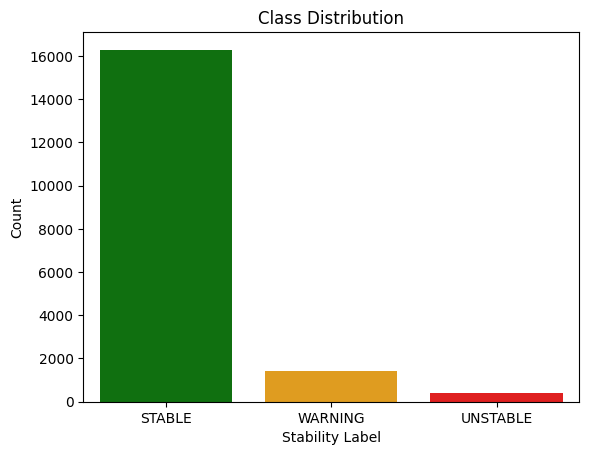

In [ ]:
sns.countplot(data=df, x='Stability Label', palette=['green', 'orange', 'red'])
plt.title('Class Distribution')
plt.ylabel('Count')
plt.show()

/tmp/ipykernel_6974/3682568393.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Stability Label', y='Voltage Magnitude', palette=['green', 'orange', 'red'])


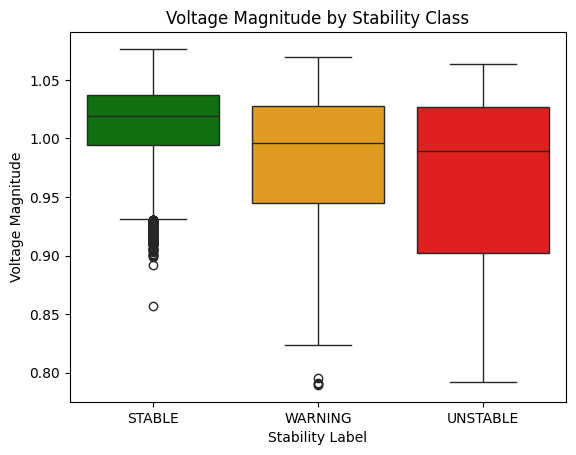

In [ ]:
sns.boxplot(data=df, x='Stability Label', y='Voltage Magnitude', palette=['green', 'orange', 'red'])
plt.title('Voltage Magnitude by Stability Class')
plt.show()

In [ ]:
df = df.copy()
df['label_numeric'] = df['Stability Label'].map({'STABLE': 0, 'WARNING': 1, 'UNSTABLE': 2})

In [ ]:
corr = df[['Voltage Magnitude', 'Voltage Angle', 'freq_hz', 'Load Factor', 'Line Outage', 'label_numeric']].corr()
print(corr['label_numeric'].sort_values(ascending=False))

label_numeric        1.000000
Load Factor          0.232016
freq_hz              0.003685
Line Outage         -0.033780
Voltage Angle       -0.234239
Voltage Magnitude   -0.283843
Name: label_numeric, dtype: float64


Voltage Magnitude → -0.284
Strongest predictor. As voltage drops, instability increases.

Voltage Angle → -0.234
Second strongest. As angle becomes more negative, instability increases. Also physically correct — large angle differences between buses indicate heavy power flow and stress.

Load Factor → +0.232
Third strongest. As load increases, instability increases.

In [ ]:
df['voltage_deviation'] = abs(df['Voltage Magnitude'] - 1.0)
df['stress_index'] = df['Load Factor'] * df['voltage_deviation']

High load × high deviation = very high stress index = danger

High load × low deviation = moderate stress index = coping

Low load × high deviation = moderate stress index = something wrong structurally

Low load × low deviation = very low stress index = healthy



In [ ]:
corr = df[['Voltage Magnitude', 'Voltage Angle', 'Load Factor',
           'voltage_deviation', 'stress_index', 'label_numeric']].corr()
print(corr['label_numeric'].sort_values(ascending=False))

label_numeric        1.000000
stress_index         0.318054
voltage_deviation    0.261305
Load Factor          0.232016
Voltage Angle       -0.234239
Voltage Magnitude   -0.283843
Name: label_numeric, dtype: float64


In [ ]:
df.to_csv('voltage_stability_features.csv', index=False)
print(df.shape)
print(df.columns.tolist())

(18149, 10)
['Bus ID', 'Voltage Magnitude', 'Voltage Angle', 'freq_hz', 'Load Factor', 'Line Outage', 'Stability Label', 'label_numeric', 'voltage_deviation', 'stress_index']


In [ ]:
from google.colab import files
files.download('voltage_stability_features.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>